# 03 — Latent Space Analysis
Deep dive into the trained VAE's latent representations:
- t-SNE and UMAP visualisation by UPOS, morphological features, dependency relations
- Linear probing accuracy per subspace per linguistic category
- Correlation heatmaps between latent dimensions and linguistic features
- Disentanglement metrics: MIG and DCI
- Latent traversal: interpolation between two sentences

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import json
import matplotlib.pyplot as plt

from src.models.vae import MorphoSyntaxVAE
from src.utils.config_loader import load_config
from src.utils.cuda_utils import get_device
from src.utils.seed import set_seed

set_seed(42)
device = get_device()

model_cfg = load_config('model_config', config_dir='../configs')
enc_cfg = model_cfg['encoder']
lat_cfg = model_cfg['latent_space']

print('Loading trained model from best checkpoint...')
checkpoint = torch.load('../outputs/checkpoints/best.pt', map_location=device)
vocab_size = checkpoint['model_state_dict']['encoder.embedding.weight'].shape[0]

model = MorphoSyntaxVAE(
    vocab_size=vocab_size,
    embedding_dim=enc_cfg['embedding_dim'],
    hidden_dim=enc_cfg['hidden_dim'],
    z_dim=lat_cfg['z_dim'],
    morpho_dim=lat_cfg['morpho_dim'],
    syntax_dim=lat_cfg['syntax_dim'],
    num_layers=enc_cfg['num_layers'],
    dropout=0.0,
    pad_idx=0,
    encoder_type=enc_cfg['type'],
    prior_type=lat_cfg['prior'],
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print('Model loaded.')

Loading trained model from best checkpoint...
Model loaded.


In [2]:
# Load dev data and extract representations
from src.data.conllu_parser import load_conllu_sentences
from src.data.vocabulary import Vocabulary
from src.data.dataset import build_dataloaders
from src.analysis.latent_probing import extract_latent_representations
from collections import Counter

data_cfg = load_config('data_config', config_dir='../configs')
paths = data_cfg['paths']

train_sents = load_conllu_sentences('../' + paths['ud_english_train'])
dev_sents   = load_conllu_sentences('../' + paths['ud_english_dev'])
test_sents  = load_conllu_sentences('../' + paths['ud_english_test'])

vocab      = Vocabulary.load('../data/processed/vocab.json')
upos_vocab = Vocabulary(max_size=50, min_freq=1)
for s in train_sents:
    upos_vocab.update(s.upos_tags)
upos_vocab.build()

deprel_vocab = Vocabulary(max_size=100, min_freq=1)
for s in train_sents:
    deprel_vocab.update(s.deprels)
deprel_vocab.build()

_, dev_loader, _ = build_dataloaders(
    train_sents, dev_sents, test_sents,
    vocab, upos_vocab, deprel_vocab,
    batch_size=128, max_len=50, num_workers=2
)

print('Extracting latent representations from dev set...')
z_all, upos_all, morph_all = extract_latent_representations(
    model, dev_loader, device, use_mean=True
)
print(f'z_all shape: {z_all.shape}')

upos_flat = [Counter(sent.upos_tags).most_common(1)[0][0] if sent.upos_tags else 'X' for sent in dev_sents[:len(z_all)]]

2026-04-02 13:45:48.193605: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Extracting latent representations from dev set...
z_all shape: (1889, 128)


Running t-SNE (this may take a few minutes)...


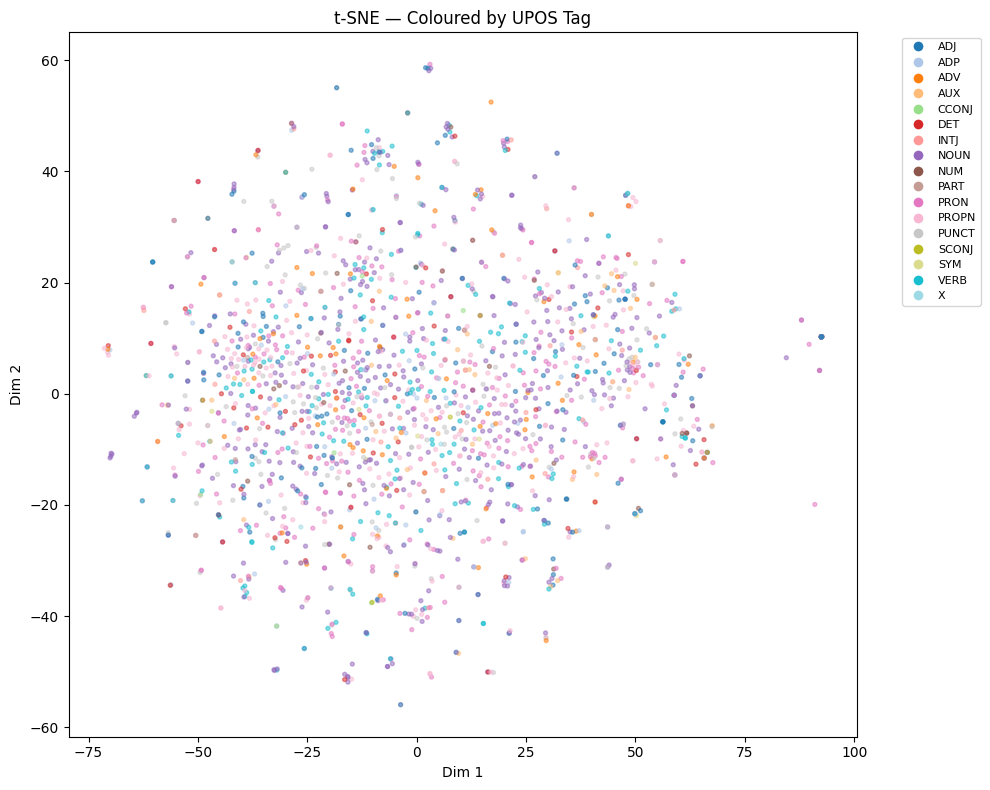

Running UMAP...


/home/rene/miniconda3/envs/image_mining/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


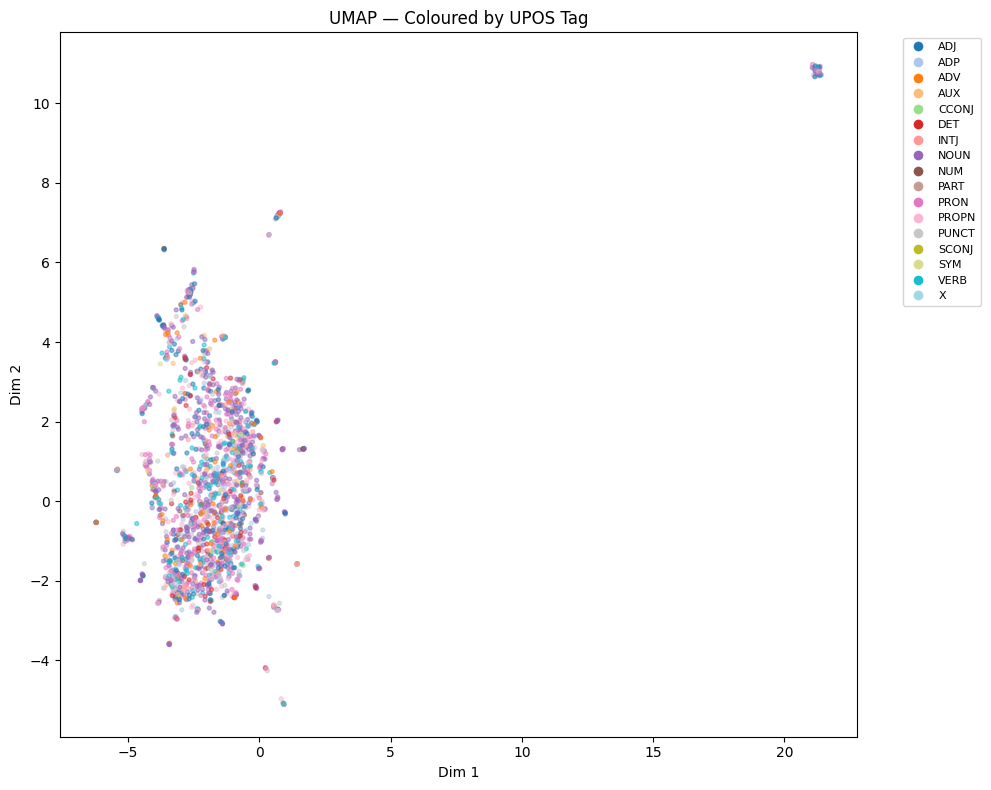

In [3]:
# t-SNE visualisation
from src.analysis.visualization import reduce_tsne, reduce_umap, plot_latent_scatter

print('Running t-SNE (this may take a few minutes)...')
z_tsne = reduce_tsne(z_all, perplexity=30, n_iter=1000)
fig = plot_latent_scatter(
    z_tsne, upos_flat,
    title='t-SNE — Coloured by UPOS Tag',
    save_path='../outputs/figures/tsne_upos_analysis.png'
)
plt.show()

print('Running UMAP...')
z_umap = reduce_umap(z_all)
fig2 = plot_latent_scatter(
    z_umap, upos_flat,
    title='UMAP — Coloured by UPOS Tag',
    save_path='../outputs/figures/umap_upos_analysis.png'
)
plt.show()

In [4]:
# Probing classifiers
from src.analysis.latent_probing import probe_subspaces

# Build per-token tense labels from morphological features
tense_flat = []
for feats_list in morph_all:
    if feats_list:
        tense = feats_list[0].get('Tense', 'None')
    else:
        tense = 'None'
    tense_flat.append(tense)

number_flat = []
for feats_list in morph_all:
    if feats_list:
        number = feats_list[0].get('Number', 'None')
    else:
        number = 'None'
    number_flat.append(number)

labels_dict = {
    'upos':   upos_flat,
    'tense':  tense_flat,
    'number': number_flat,
}

print('Running probing classifiers...')
probe_results = probe_subspaces(
    z_all,
    morpho_dim=lat_cfg['morpho_dim'],
    labels_dict=labels_dict
)
print(json.dumps(probe_results, indent=2))

Running probing classifiers...


/home/rene/miniconda3/envs/image_mining/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/rene/miniconda3/envs/image_mining/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/rene/miniconda3/envs/image_mining/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/rene/miniconda3/envs/image_mining/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated

{
  "morpho": {
    "upos": {
      "accuracy_mean": 0.25780809229085094,
      "accuracy_std": 0.001210660630263623,
      "f1_macro_mean": 0.02562067771812256,
      "f1_macro_std": 9.562756882656332e-05,
      "n_classes": 17,
      "classes": [
        "ADJ",
        "ADP",
        "ADV",
        "AUX",
        "CCONJ",
        "DET",
        "INTJ",
        "NOUN",
        "NUM",
        "PART",
        "PRON",
        "PROPN",
        "PUNCT",
        "SCONJ",
        "SYM",
        "VERB",
        "X"
      ]
    },
    "tense": {
      "accuracy_mean": 0.9497087841915428,
      "accuracy_std": 5.333108781386819e-05,
      "f1_macro_mean": 0.32473526000178454,
      "f1_macro_std": 9.353356901353748e-06,
      "n_classes": 3,
      "classes": [
        "None",
        "Past",
        "Pres"
      ]
    },
    "number": {
      "accuracy_mean": 0.5574375815755126,
      "accuracy_std": 0.0010447492831497777,
      "f1_macro_mean": 0.19088474469682476,
      "f1_macro_std": 0.0238

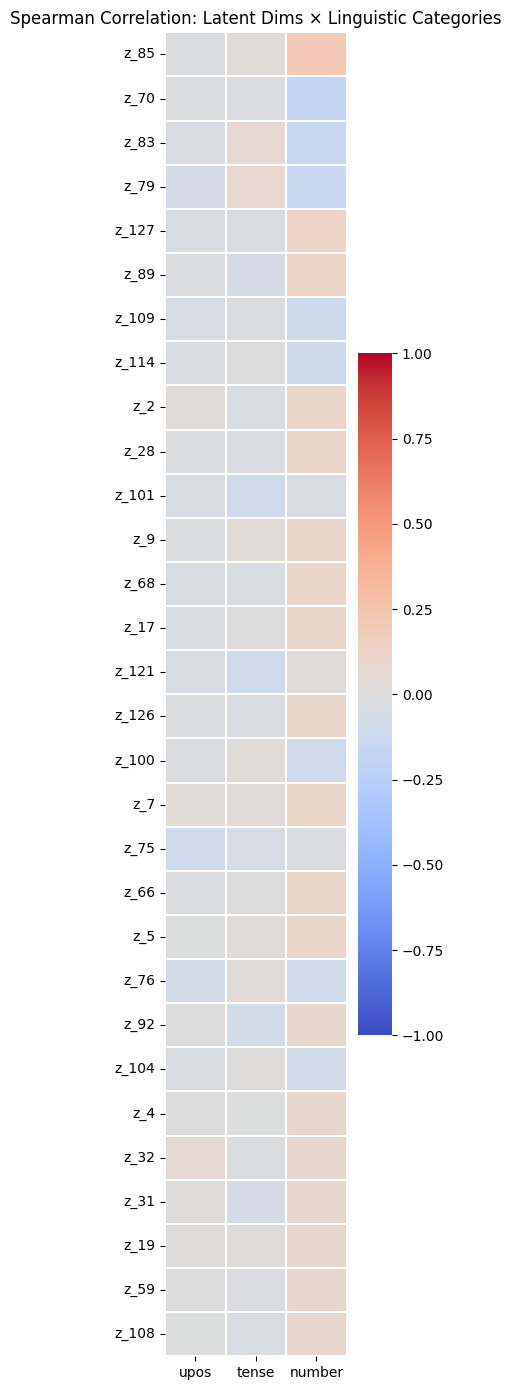

In [5]:
# Correlation heatmap
from src.analysis.correlation import correlation_matrix
from src.analysis.visualization import plot_correlation_heatmap

corr_mat, categories = correlation_matrix(
    z_all, labels_dict, method='spearman'
)
fig3 = plot_correlation_heatmap(
    corr_mat, categories,
    top_dims=30,
    title='Spearman Correlation: Latent Dims × Linguistic Categories',
    save_path='../outputs/figures/correlation_heatmap_analysis.png'
)
plt.show()

In [6]:
# Latent interpolation between two sentences
print('Latent interpolation demo...')

sent_a = dev_sents[0]
sent_b = dev_sents[10]

ids_a = torch.tensor(
    vocab.encode(sent_a.forms, add_special=True), dtype=torch.long
).unsqueeze(0).to(device)
ids_b = torch.tensor(
    vocab.encode(sent_b.forms, add_special=True), dtype=torch.long
).unsqueeze(0).to(device)

len_a = torch.tensor([len(sent_a.forms)])
len_b = torch.tensor([len(sent_b.forms)])

with torch.no_grad():
    mu_a, _ = model.encode(ids_a, len_a.to(device))
    mu_b, _ = model.encode(ids_b, len_b.to(device))

print(f'Sentence A: {" ".join(sent_a.forms)}')
print(f'Sentence B: {" ".join(sent_b.forms)}')
print()

alphas = np.linspace(0, 1, 6)
for alpha in alphas:
    z_interp = ((1 - alpha) * mu_a + alpha * mu_b).to(device)
    with torch.no_grad():
        gen = model.generate(
            z_interp, bos_idx=vocab.bos_idx,
            eos_idx=vocab.eos_idx, max_len=30
        )
    tokens = vocab.decode(gen[0].tolist(), remove_special=True)
    print(f'  alpha={alpha:.1f}: {" ".join(tokens)}')

Latent interpolation demo...
Sentence A: From the AP comes this story :
Sentence B: In the eastern city of Baqubah , guerrillas detonated a car bomb outside a police station , killing several people .

  alpha=0.0: I have been a of the and .
  alpha=0.2: I have been a of the and .
  alpha=0.4: I have been a of the and .
  alpha=0.6: I have been a of the and .
  alpha=0.8: I have been a of the and .
  alpha=1.0: I have been a of the and .
